# Feature Scaling in Machine Learning: Complete Guide

This notebook explains **why**, **when**, and **how** to scale features in machine learning.

## Table of Contents
1. What is Feature Scaling?
2. Why Do We Need Scaling?
3. Types of Scaling
4. When to Use Each Method
5. Practical Examples with kNN
6. Common Mistakes to Avoid

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

---
## 1. What is Feature Scaling?

**Feature scaling** transforms features to a similar scale so no single feature dominates due to its magnitude.

### Example Problem

In [3]:
# House data: [size in sq ft, number of bedrooms]
house_data = np.array([
    [2000, 3],  # 2000 sq ft, 3 bedrooms
    [1500, 2],  # 1500 sq ft, 2 bedrooms
    [3000, 4],  # 3000 sq ft, 4 bedrooms
])

print("Original data:")
print("Size (sq ft) | Bedrooms")
print("-------------|----------")
for row in house_data:
    print(f"    {row[0]:4d}     |    {row[1]}")

print("\n⚠️ PROBLEM: Size ranges from 1500-3000, bedrooms only 2-4")
print("Size will dominate distance calculations!")

Original data:
Size (sq ft) | Bedrooms
-------------|----------
    2000     |    3
    1500     |    2
    3000     |    4

⚠️ PROBLEM: Size ranges from 1500-3000, bedrooms only 2-4
Size will dominate distance calculations!


---
## 2. Why Do We Need Scaling?

### Problem: Distance-based algorithms are sensitive to scale

In [4]:
# Two houses we want to compare
house_A = np.array([2000, 3])  # 2000 sq ft, 3 bedrooms
house_B = np.array([2100, 2])  # 2100 sq ft, 2 bedrooms

# Calculate Euclidean distance WITHOUT scaling
diff = house_A - house_B
print("Difference between houses:")
print(f"  Size: {diff[0]} sq ft")
print(f"  Bedrooms: {diff[1]} bedrooms")

# Squared differences
squared_diff = diff ** 2
print(f"\nSquared differences:")
print(f"  Size: {squared_diff[0]:,}")
print(f"  Bedrooms: {squared_diff[1]}")

distance = np.sqrt(np.sum(squared_diff))
print(f"\nEuclidean distance: {distance:.2f}")

print("\n💡 Notice: The size difference (100) dominates!")
print("   Bedroom difference (1) barely affects the distance.")
print("   The algorithm will ignore bedrooms almost entirely!")

Difference between houses:
  Size: -100 sq ft
  Bedrooms: 1 bedrooms

Squared differences:
  Size: 10,000
  Bedrooms: 1

Euclidean distance: 100.00

💡 Notice: The size difference (100) dominates!
   Bedroom difference (1) barely affects the distance.
   The algorithm will ignore bedrooms almost entirely!


### Visualization: Why Scaling Matters

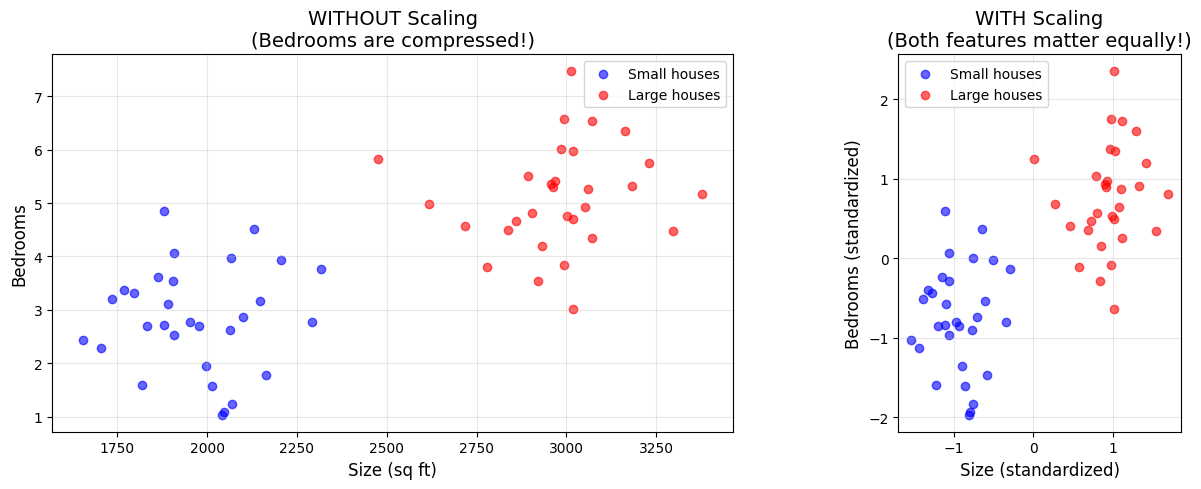

👀 Look at the difference!
   Left: Bedrooms are squished (0-10 range vs 1500-3500)
   Right: Both features have equal importance


In [5]:
# Create sample data
np.random.seed(42)
class_0 = np.random.randn(30, 2) * [200, 1] + [2000, 3]  # Around 2000 sq ft, 3 beds
class_1 = np.random.randn(30, 2) * [200, 1] + [3000, 5]  # Around 3000 sq ft, 5 beds

# Plot unscaled data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Unscaled
axes[0].scatter(class_0[:, 0], class_0[:, 1], c='blue', label='Small houses', alpha=0.6)
axes[0].scatter(class_1[:, 0], class_1[:, 1], c='red', label='Large houses', alpha=0.6)
axes[0].set_xlabel('Size (sq ft)', fontsize=12)
axes[0].set_ylabel('Bedrooms', fontsize=12)
axes[0].set_title('WITHOUT Scaling\n(Bedrooms are compressed!)', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Scaled
scaler = StandardScaler()
all_data = np.vstack([class_0, class_1])
scaled_data = scaler.fit_transform(all_data)
scaled_0 = scaled_data[:30]
scaled_1 = scaled_data[30:]

axes[1].scatter(scaled_0[:, 0], scaled_0[:, 1], c='blue', label='Small houses', alpha=0.6)
axes[1].scatter(scaled_1[:, 0], scaled_1[:, 1], c='red', label='Large houses', alpha=0.6)
axes[1].set_xlabel('Size (standardized)', fontsize=12)
axes[1].set_ylabel('Bedrooms (standardized)', fontsize=12)
axes[1].set_title('WITH Scaling\n(Both features matter equally!)', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print("👀 Look at the difference!")
print("   Left: Bedrooms are squished (0-10 range vs 1500-3500)")
print("   Right: Both features have equal importance")

---
## 3. Types of Scaling

### 3.1 Min-Max Scaling (Normalization)

**Formula:** $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

**Result:** Values between 0 and 1

In [6]:
# Original data
data = np.array([[2000, 3],
                 [1500, 2],
                 [3000, 4],
                 [2500, 3]])

print("=" * 60)
print("MIN-MAX SCALING (Normalization)")
print("=" * 60)

# Manual calculation for understanding
print("\n📊 Original data:")
print(data)

# Calculate min and max for each feature
min_vals = data.min(axis=0)
max_vals = data.max(axis=0)

print(f"\nMin values: {min_vals}  (per feature)")
print(f"Max values: {max_vals}  (per feature)")

# Apply formula
scaled_manual = (data - min_vals) / (max_vals - min_vals)

print("\n📐 Formula: (X - min) / (max - min)")
print("\nFor first house [2000, 3]:")
print(f"  Size: (2000 - 1500) / (3000 - 1500) = 500/1500 = {scaled_manual[0, 0]:.2f}")
print(f"  Beds: (3 - 2) / (4 - 2) = 1/2 = {scaled_manual[0, 1]:.2f}")

print("\n✅ Scaled data (manual):")
print(scaled_manual)

# Using sklearn
scaler = MinMaxScaler()
scaled_sklearn = scaler.fit_transform(data)

print("\n✅ Scaled data (sklearn):")
print(scaled_sklearn)

print("\n💡 Key points:")
print("   • All values are now between 0 and 1")
print("   • Smallest value becomes 0, largest becomes 1")
print("   • Use when: data has no outliers, you need bounded range")

MIN-MAX SCALING (Normalization)

📊 Original data:
[[2000    3]
 [1500    2]
 [3000    4]
 [2500    3]]

Min values: [1500    2]  (per feature)
Max values: [3000    4]  (per feature)

📐 Formula: (X - min) / (max - min)

For first house [2000, 3]:
  Size: (2000 - 1500) / (3000 - 1500) = 500/1500 = 0.33
  Beds: (3 - 2) / (4 - 2) = 1/2 = 0.50

✅ Scaled data (manual):
[[0.33333333 0.5       ]
 [0.         0.        ]
 [1.         1.        ]
 [0.66666667 0.5       ]]

✅ Scaled data (sklearn):
[[0.33333333 0.5       ]
 [0.         0.        ]
 [1.         1.        ]
 [0.66666667 0.5       ]]

💡 Key points:
   • All values are now between 0 and 1
   • Smallest value becomes 0, largest becomes 1
   • Use when: data has no outliers, you need bounded range


### 3.2 Standardization (Z-score normalization)

**Formula:** $X_{scaled} = \frac{X - \mu}{\sigma}$

where:
- $\mu$ = mean
- $\sigma$ = standard deviation

**Result:** Mean = 0, Standard Deviation = 1

In [7]:
print("=" * 60)
print("STANDARDIZATION (Z-score)")
print("=" * 60)

data = np.array([[2000, 3],
                 [1500, 2],
                 [3000, 4],
                 [2500, 3]])

print("\n📊 Original data:")
print(data)

# Calculate mean and std
mean = data.mean(axis=0)
std = data.std(axis=0)

print(f"\nMean: {mean}")
print(f"Std:  {std}")

# Apply formula
scaled_manual = (data - mean) / std

print("\n📐 Formula: (X - mean) / std")
print("\nFor first house [2000, 3]:")
print(f"  Size: (2000 - {mean[0]:.1f}) / {std[0]:.1f} = {scaled_manual[0, 0]:.2f}")
print(f"  Beds: (3 - {mean[1]:.1f}) / {std[1]:.2f} = {scaled_manual[0, 1]:.2f}")

print("\n✅ Scaled data (manual):")
print(scaled_manual)

# Verify mean and std
print(f"\nVerification:")
print(f"  Mean after scaling: {scaled_manual.mean(axis=0)}")
print(f"  Std after scaling:  {scaled_manual.std(axis=0)}")

# Using sklearn
scaler = StandardScaler()
scaled_sklearn = scaler.fit_transform(data)

print("\n✅ Scaled data (sklearn):")
print(scaled_sklearn)

print("\n💡 Key points:")
print("   • Mean becomes 0, std becomes 1")
print("   • Values can be negative")
print("   • Values typically range from -3 to +3")
print("   • Use when: data is normally distributed, has outliers")
print("   • MOST COMMON choice for ML!")

STANDARDIZATION (Z-score)

📊 Original data:
[[2000    3]
 [1500    2]
 [3000    4]
 [2500    3]]

Mean: [2250.    3.]
Std:  [559.01699437   0.70710678]

📐 Formula: (X - mean) / std

For first house [2000, 3]:
  Size: (2000 - 2250.0) / 559.0 = -0.45
  Beds: (3 - 3.0) / 0.71 = 0.00

✅ Scaled data (manual):
[[-0.4472136   0.        ]
 [-1.34164079 -1.41421356]
 [ 1.34164079  1.41421356]
 [ 0.4472136   0.        ]]

Verification:
  Mean after scaling: [1.38777878e-17 0.00000000e+00]
  Std after scaling:  [1. 1.]

✅ Scaled data (sklearn):
[[-0.4472136   0.        ]
 [-1.34164079 -1.41421356]
 [ 1.34164079  1.41421356]
 [ 0.4472136   0.        ]]

💡 Key points:
   • Mean becomes 0, std becomes 1
   • Values can be negative
   • Values typically range from -3 to +3
   • Use when: data is normally distributed, has outliers
   • MOST COMMON choice for ML!


### 3.3 Robust Scaling

**Formula:** $X_{scaled} = \frac{X - median}{IQR}$

where IQR = 75th percentile - 25th percentile

**Use when:** You have outliers

ROBUST SCALING (for data with outliers)

📊 Original data (with outlier):
[[ 2000     3]
 [ 1500     2]
 [ 3000     4]
 [ 2500     3]
 [10000     3]]

⚠️ Notice the 10,000 sq ft house (outlier)!


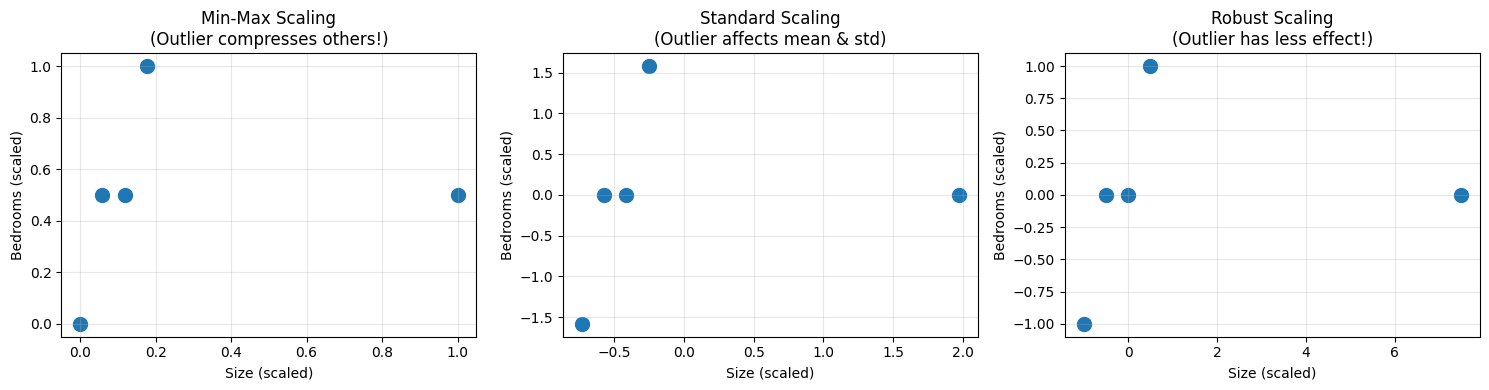


✅ Robust scaled data:
[[-0.5  0. ]
 [-1.  -1. ]
 [ 0.5  1. ]
 [ 0.   0. ]
 [ 7.5  0. ]]

💡 Key points:
   • Uses median instead of mean
   • Uses IQR instead of std
   • Resistant to outliers
   • Use when: you have outliers you can't remove


In [8]:
print("=" * 60)
print("ROBUST SCALING (for data with outliers)")
print("=" * 60)

# Data with outlier
data_with_outlier = np.array([[2000, 3],
                               [1500, 2],
                               [3000, 4],
                               [2500, 3],
                               [10000, 3]])  # OUTLIER!

print("\n📊 Original data (with outlier):")
print(data_with_outlier)
print("\n⚠️ Notice the 10,000 sq ft house (outlier)!")

# Compare all three methods
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MinMax
minmax_scaler = MinMaxScaler()
scaled_minmax = minmax_scaler.fit_transform(data_with_outlier)
axes[0].scatter(scaled_minmax[:, 0], scaled_minmax[:, 1], s=100)
axes[0].set_title('Min-Max Scaling\n(Outlier compresses others!)', fontsize=12)
axes[0].set_xlabel('Size (scaled)')
axes[0].set_ylabel('Bedrooms (scaled)')
axes[0].grid(True, alpha=0.3)

# Standard
standard_scaler = StandardScaler()
scaled_standard = standard_scaler.fit_transform(data_with_outlier)
axes[1].scatter(scaled_standard[:, 0], scaled_standard[:, 1], s=100)
axes[1].set_title('Standard Scaling\n(Outlier affects mean & std)', fontsize=12)
axes[1].set_xlabel('Size (scaled)')
axes[1].set_ylabel('Bedrooms (scaled)')
axes[1].grid(True, alpha=0.3)

# Robust
robust_scaler = RobustScaler()
scaled_robust = robust_scaler.fit_transform(data_with_outlier)
axes[2].scatter(scaled_robust[:, 0], scaled_robust[:, 1], s=100)
axes[2].set_title('Robust Scaling\n(Outlier has less effect!)', fontsize=12)
axes[2].set_xlabel('Size (scaled)')
axes[2].set_ylabel('Bedrooms (scaled)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Robust scaled data:")
print(scaled_robust)

print("\n💡 Key points:")
print("   • Uses median instead of mean")
print("   • Uses IQR instead of std")
print("   • Resistant to outliers")
print("   • Use when: you have outliers you can't remove")

### Comparison: All Three Methods Side by Side

In [9]:
# Create comparison table
data = np.array([[2000, 3],
                 [1500, 2],
                 [3000, 4],
                 [2500, 3]])

# Apply all scalers
minmax = MinMaxScaler().fit_transform(data)
standard = StandardScaler().fit_transform(data)
robust = RobustScaler().fit_transform(data)

# Create DataFrame for pretty printing
df = pd.DataFrame({
    'Original_Size': data[:, 0],
    'Original_Beds': data[:, 1],
    'MinMax_Size': minmax[:, 0],
    'MinMax_Beds': minmax[:, 1],
    'Standard_Size': standard[:, 0],
    'Standard_Beds': standard[:, 1],
    'Robust_Size': robust[:, 0],
    'Robust_Beds': robust[:, 1],
})

print("\n" + "=" * 100)
print("COMPARISON: All Scaling Methods")
print("=" * 100)
print(df.to_string(index=False))

print("\n📊 Summary:")
print("\nMin-Max:")
print(f"  Range: [{minmax.min():.2f}, {minmax.max():.2f}]")
print("\nStandardization:")
print(f"  Mean: {standard.mean():.10f}")
print(f"  Std:  {standard.std():.2f}")
print("\nRobust:")
print(f"  Median: {np.median(robust, axis=0)}")


COMPARISON: All Scaling Methods
 Original_Size  Original_Beds  MinMax_Size  MinMax_Beds  Standard_Size  Standard_Beds  Robust_Size  Robust_Beds
          2000              3     0.333333          0.5      -0.447214       0.000000    -0.333333          0.0
          1500              2     0.000000          0.0      -1.341641      -1.414214    -1.000000         -2.0
          3000              4     1.000000          1.0       1.341641       1.414214     1.000000          2.0
          2500              3     0.666667          0.5       0.447214       0.000000     0.333333          0.0

📊 Summary:

Min-Max:
  Range: [0.00, 1.00]

Standardization:
  Mean: 0.0000000000
  Std:  1.00

Robust:
  Median: [0. 0.]


---
## 4. When to Use Each Method

### Decision Tree

In [10]:
print("""
┌─────────────────────────────────────────────────────────┐
│            WHICH SCALING METHOD TO USE?                 │
└─────────────────────────────────────────────────────────┘

START HERE
    |
    v
Does your algorithm use distances/gradients?
    ├─ NO ──> Tree-based models (Random Forest, XGBoost)
    |         ➜ NO SCALING NEEDED!
    |
    └─ YES ──> Do you have outliers?
                |
                ├─ YES ──> Use ROBUST SCALING
                |          ➜ RobustScaler()
                |
                └─ NO ──> Do you need values in [0, 1]?
                           |
                           ├─ YES ──> Use MIN-MAX SCALING
                           |          ➜ MinMaxScaler()
                           |          Examples: Neural networks with sigmoid/tanh
                           |                    Image processing (0-255 → 0-1)
                           |
                           └─ NO ──> Use STANDARDIZATION ⭐ (Most common!)
                                     ➜ StandardScaler()
                                     Examples: kNN, SVM, Linear/Logistic Regression
                                              Neural networks, K-means, PCA

""")

# Create reference table
algorithms_table = pd.DataFrame({
    'Algorithm': ['kNN', 'SVM', 'Linear/Logistic Regression', 'Neural Networks',
                  'K-Means', 'PCA', 'Random Forest', 'XGBoost', 'Decision Trees'],
    'Needs Scaling?': ['YES ✓', 'YES ✓', 'YES ✓', 'YES ✓',
                       'YES ✓', 'YES ✓', 'NO ✗', 'NO ✗', 'NO ✗'],
    'Preferred Method': ['Standard/Robust', 'Standard', 'Standard', 'MinMax or Standard',
                         'Standard', 'Standard', 'None', 'None', 'None']
})

print("\n" + "="*70)
print("QUICK REFERENCE: Common Algorithms")
print("="*70)
print(algorithms_table.to_string(index=False))


┌─────────────────────────────────────────────────────────┐
│            WHICH SCALING METHOD TO USE?                 │
└─────────────────────────────────────────────────────────┘

START HERE
    |
    v
Does your algorithm use distances/gradients?
    ├─ NO ──> Tree-based models (Random Forest, XGBoost)
    |         ➜ NO SCALING NEEDED!
    |
    └─ YES ──> Do you have outliers?
                |
                ├─ YES ──> Use ROBUST SCALING
                |          ➜ RobustScaler()
                |
                └─ NO ──> Do you need values in [0, 1]?
                           |
                           ├─ YES ──> Use MIN-MAX SCALING
                           |          ➜ MinMaxScaler()
                           |          Examples: Neural networks with sigmoid/tanh
                           |                    Image processing (0-255 → 0-1)
                           |
                           └─ NO ──> Use STANDARDIZATION ⭐ (Most common!)
                           

---
## 5. Practical Example: kNN with and without Scaling

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("=" * 70)
print("REAL EXAMPLE: kNN on Breast Cancer Dataset")
print("=" * 70)

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

print(f"\nDataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {len(np.unique(y))} (benign vs malignant)")

# Look at feature ranges
print("\n📊 Feature ranges (first 5 features):")
for i in range(5):
    print(f"  {data.feature_names[i]:25s}: [{X[:, i].min():8.2f}, {X[:, i].max():8.2f}]")

print("\n⚠️ Features have VERY different scales!")
print("   This will cause problems for kNN...\n")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("=" * 70)
print("Test 1: WITHOUT Scaling")
print("=" * 70)

# Without scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
pred_no_scale = knn_no_scale.predict(X_test)
acc_no_scale = accuracy_score(y_test, pred_no_scale)

print(f"Accuracy WITHOUT scaling: {acc_no_scale*100:.2f}%")

print("\n=" * 70)
print("Test 2: WITH Standardization")
print("=" * 70)

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, pred_scaled)

print(f"Accuracy WITH scaling:    {acc_scaled*100:.2f}%")

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)
print(f"\n{'Method':<20} {'Accuracy':<15} {'Improvement'}")
print("-" * 50)
print(f"{'Without Scaling':<20} {acc_no_scale*100:>6.2f}%")
print(f"{'With Scaling':<20} {acc_scaled*100:>6.2f}%        {'↑ ' + f'{(acc_scaled-acc_no_scale)*100:.2f}%'}")

print("\n✅ Scaling improved accuracy!")
print("   Large features no longer dominate the distance calculations.")

REAL EXAMPLE: kNN on Breast Cancer Dataset

Dataset: 569 samples, 30 features
Classes: 2 (benign vs malignant)

📊 Feature ranges (first 5 features):
  mean radius              : [    6.98,    28.11]
  mean texture             : [    9.71,    39.28]
  mean perimeter           : [   43.79,   188.50]
  mean area                : [  143.50,  2501.00]
  mean smoothness          : [    0.05,     0.16]

⚠️ Features have VERY different scales!
   This will cause problems for kNN...

Test 1: WITHOUT Scaling
Accuracy WITHOUT scaling: 95.91%

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
Test 2: WITH Standardization
Accuracy WITH scaling:    95.91%

RESULTS

Method               Accuracy        Improvement
--------------------------------------------------
Without Scaling       95.91%
With Scaling          95.91%        ↑ 0.00%

✅ Scaling improved accuracy!
   Large features no longer dominate the distan

### Visualizing the Effect on Distances

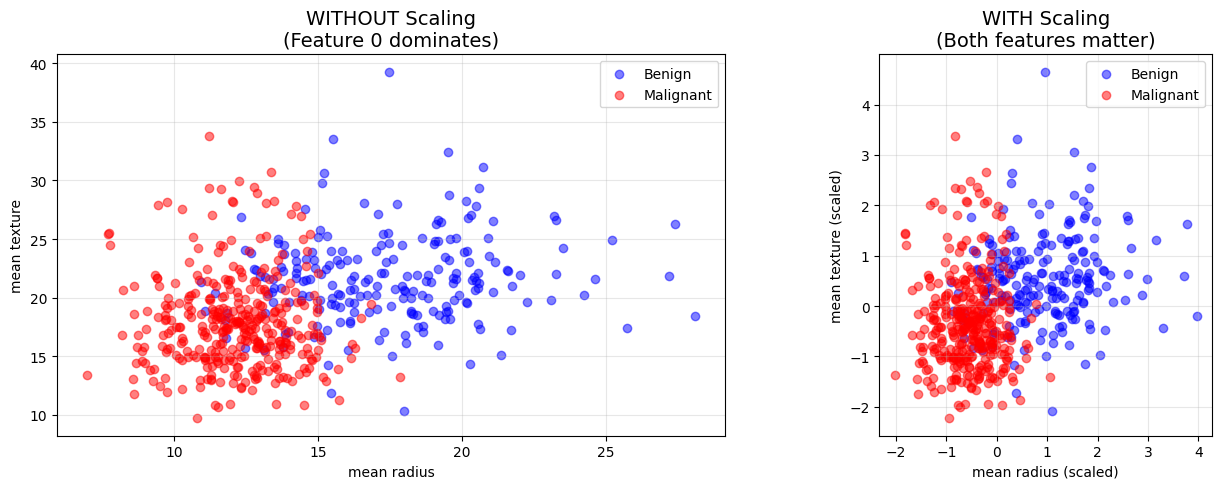

In [12]:
# Take first 2 features for visualization
X_2d = X[:, :2]
X_2d_scaled = StandardScaler().fit_transform(X_2d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unscaled
axes[0].scatter(X_2d[y==0, 0], X_2d[y==0, 1], c='blue', alpha=0.5, label='Benign')
axes[0].scatter(X_2d[y==1, 0], X_2d[y==1, 1], c='red', alpha=0.5, label='Malignant')
axes[0].set_xlabel(data.feature_names[0])
axes[0].set_ylabel(data.feature_names[1])
axes[0].set_title('WITHOUT Scaling\n(Feature 0 dominates)', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scaled
axes[1].scatter(X_2d_scaled[y==0, 0], X_2d_scaled[y==0, 1], c='blue', alpha=0.5, label='Benign')
axes[1].scatter(X_2d_scaled[y==1, 0], X_2d_scaled[y==1, 1], c='red', alpha=0.5, label='Malignant')
axes[1].set_xlabel(f'{data.feature_names[0]} (scaled)')
axes[1].set_ylabel(f'{data.feature_names[1]} (scaled)')
axes[1].set_title('WITH Scaling\n(Both features matter)', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 6. Common Mistakes to Avoid

### ❌ MISTAKE 1: Fitting scaler on entire dataset (Data Leakage!)

In [13]:
print("=" * 70)
print("MISTAKE 1: Data Leakage")
print("=" * 70)

print("""
❌ WRONG WAY (Data Leakage):

    # Fit on ALL data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # ← WRONG!
    
    # Then split
    X_train, X_test = train_test_split(X_scaled)
    
    ⚠️ Problem: Test data influenced the scaling!
               The mean/std include test data information.
               This gives unrealistic performance estimates.

✅ RIGHT WAY:

    # Split FIRST
    X_train, X_test = train_test_split(X)
    
    # Fit on train only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # ← Fit on train
    X_test_scaled = scaler.transform(X_test)         # ← Only transform test
    
    ✓ Test data doesn't influence scaling parameters!
""")

# Demonstrate the difference
X_sample = np.array([[1, 10],
                     [2, 20],
                     [3, 30],
                     [100, 1000]])  # Test data with outlier

X_train_sample = X_sample[:3]
X_test_sample = X_sample[3:]

print("\nExample:")
print(f"Train: {X_train_sample.tolist()}")
print(f"Test:  {X_test_sample.tolist()} ← outlier!\n")

# Wrong way
scaler_wrong = StandardScaler()
X_all_scaled = scaler_wrong.fit_transform(X_sample)
print("❌ Wrong way (fit on all):")
print(f"   Mean used: {scaler_wrong.mean_}")
print(f"   Std used:  {scaler_wrong.scale_}")
print(f"   Train scaled: {X_all_scaled[:3].tolist()}")

# Right way
scaler_right = StandardScaler()
X_train_scaled = scaler_right.fit_transform(X_train_sample)
X_test_scaled = scaler_right.transform(X_test_sample)
print("\n✅ Right way (fit on train only):")
print(f"   Mean used: {scaler_right.mean_}")
print(f"   Std used:  {scaler_right.scale_}")
print(f"   Train scaled: {X_train_scaled.tolist()}")

print("\n📊 Notice: Different means and stds!")
print("   Wrong way: Test outlier affected the scaling")
print("   Right way: Only train data affected the scaling")

MISTAKE 1: Data Leakage

❌ WRONG WAY (Data Leakage):

    # Fit on ALL data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # ← WRONG!

    # Then split
    X_train, X_test = train_test_split(X_scaled)

    ⚠️ Problem: Test data influenced the scaling!
               The mean/std include test data information.
               This gives unrealistic performance estimates.

✅ RIGHT WAY:

    # Split FIRST
    X_train, X_test = train_test_split(X)

    # Fit on train only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # ← Fit on train
    X_test_scaled = scaler.transform(X_test)         # ← Only transform test

    ✓ Test data doesn't influence scaling parameters!


Example:
Train: [[1, 10], [2, 20], [3, 30]]
Test:  [[100, 1000]] ← outlier!

❌ Wrong way (fit on all):
   Mean used: [ 26.5 265. ]
   Std used:  [ 42.44113571 424.41135706]
   Train scaled: [[-0.6008321779311374, -0.6008321779311374], [-0.5772701317377594, -0.577270131737

### ❌ MISTAKE 2: Using transform() instead of fit_transform() on training

In [14]:
print("=" * 70)
print("MISTAKE 2: Not fitting the scaler")
print("=" * 70)

print("""
❌ WRONG:
    scaler = StandardScaler()
    X_train_scaled = scaler.transform(X_train)  # ← Haven't fit yet!
    # ERROR: Scaler doesn't know mean/std yet

✅ RIGHT:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # ← Learn mean/std and transform
    X_test_scaled = scaler.transform(X_test)        # ← Use learned mean/std

Remember:
  • fit_transform() on TRAIN data (learn parameters + transform)
  • transform() on TEST data (use learned parameters)
""")

MISTAKE 2: Not fitting the scaler

❌ WRONG:
    scaler = StandardScaler()
    X_train_scaled = scaler.transform(X_train)  # ← Haven't fit yet!
    # ERROR: Scaler doesn't know mean/std yet

✅ RIGHT:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # ← Learn mean/std and transform
    X_test_scaled = scaler.transform(X_test)        # ← Use learned mean/std

Remember:
  • fit_transform() on TRAIN data (learn parameters + transform)
  • transform() on TEST data (use learned parameters)



### ❌ MISTAKE 3: Scaling target variable y

In [15]:
print("=" * 70)
print("MISTAKE 3: Scaling the labels")
print("=" * 70)

print("""
❌ WRONG:
    X_scaled = scaler.fit_transform(X)
    y_scaled = scaler.fit_transform(y)  # ← DON'T DO THIS!

✅ RIGHT:
    X_scaled = scaler.fit_transform(X)  # ← Only scale features
    # y stays unchanged for classification
    
Note: For REGRESSION, you might scale y, but that's advanced.
      For CLASSIFICATION, NEVER scale y!
""")

y_sample = np.array([0, 1, 0, 1, 0])
print(f"\nClassification labels: {y_sample}")
print("These are categories, not measurements!")
print("Scaling them makes no sense.")

MISTAKE 3: Scaling the labels

❌ WRONG:
    X_scaled = scaler.fit_transform(X)
    y_scaled = scaler.fit_transform(y)  # ← DON'T DO THIS!

✅ RIGHT:
    X_scaled = scaler.fit_transform(X)  # ← Only scale features
    # y stays unchanged for classification

Note: For REGRESSION, you might scale y, but that's advanced.
      For CLASSIFICATION, NEVER scale y!


Classification labels: [0 1 0 1 0]
These are categories, not measurements!
Scaling them makes no sense.


### ❌ MISTAKE 4: Scaling when not needed

In [16]:
print("=" * 70)
print("MISTAKE 4: Unnecessary scaling")
print("=" * 70)

print("""
Tree-based models DON'T need scaling:
  • Decision Trees
  • Random Forest
  • XGBoost
  • LightGBM

Why? They split on single features at a time.
     Scale doesn't affect where the splits happen!

Example:
  Original: "If size > 2500, then class A"
  Scaled:   "If size_scaled > 0.67, then class A"
  
  Same split, just different threshold!
  Results are identical.
""")

# Demonstrate
from sklearn.ensemble import RandomForestClassifier

print("\nDemonstration with Random Forest:")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Without scaling
rf_no_scale = RandomForestClassifier(random_state=42)
rf_no_scale.fit(X_train, y_train)
acc_no_scale = rf_no_scale.score(X_test, y_test)

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_scaled = RandomForestClassifier(random_state=42)
rf_scaled.fit(X_train_scaled, y_train)
acc_scaled = rf_scaled.score(X_test_scaled, y_test)

print(f"\nRandom Forest accuracy without scaling: {acc_no_scale*100:.2f}%")
print(f"Random Forest accuracy with scaling:    {acc_scaled*100:.2f}%")
print(f"\nDifference: {abs(acc_scaled - acc_no_scale)*100:.4f}%")
print("\n💡 Nearly identical! Scaling didn't help (or hurt).")

MISTAKE 4: Unnecessary scaling

Tree-based models DON'T need scaling:
  • Decision Trees
  • Random Forest
  • XGBoost
  • LightGBM

Why? They split on single features at a time.
     Scale doesn't affect where the splits happen!

Example:
  Original: "If size > 2500, then class A"
  Scaled:   "If size_scaled > 0.67, then class A"

  Same split, just different threshold!
  Results are identical.


Demonstration with Random Forest:

Random Forest accuracy without scaling: 97.08%
Random Forest accuracy with scaling:    97.08%

Difference: 0.0000%

💡 Nearly identical! Scaling didn't help (or hurt).


---
## 7. Complete Workflow Example

Here's the proper way to scale and train a model:

In [17]:
print("=" * 70)
print("COMPLETE WORKFLOW: Proper Way to Scale")
print("=" * 70)

print("""
Step-by-step guide:

1. Load data
2. Split into train/test FIRST
3. Create scaler
4. Fit scaler on TRAIN only
5. Transform both train and test
6. Train model
7. Evaluate
""")

# Step 1: Load data
print("\nStep 1: Loading data...")
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target
print(f"   Loaded {X.shape[0]} samples with {X.shape[1]} features")

# Step 2: Split FIRST
print("\nStep 2: Splitting into train/test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"   Train: {X_train.shape[0]} samples")
print(f"   Test:  {X_test.shape[0]} samples")

# Step 3: Create scaler
print("\nStep 3: Creating scaler...")
scaler = StandardScaler()
print("   Using StandardScaler")

# Step 4: Fit on train only
print("\nStep 4: Fitting scaler on TRAIN data only...")
X_train_scaled = scaler.fit_transform(X_train)
print(f"   Learned mean: {scaler.mean_}")
print(f"   Learned std:  {scaler.scale_}")

# Step 5: Transform test
print("\nStep 5: Transforming test data with learned parameters...")
X_test_scaled = scaler.transform(X_test)
print("   ✓ Test data scaled")

# Step 6: Train model
print("\nStep 6: Training kNN model...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("   ✓ Model trained")

# Step 7: Evaluate
print("\nStep 7: Evaluating...")
train_acc = knn.score(X_train_scaled, y_train)
test_acc = knn.score(X_test_scaled, y_test)
print(f"   Train accuracy: {train_acc*100:.2f}%")
print(f"   Test accuracy:  {test_acc*100:.2f}%")

print("\n" + "="*70)
print("✅ DONE! This is the correct workflow.")
print("="*70)

COMPLETE WORKFLOW: Proper Way to Scale

Step-by-step guide:

1. Load data
2. Split into train/test FIRST
3. Create scaler
4. Fit scaler on TRAIN only
5. Transform both train and test
6. Train model
7. Evaluate


Step 1: Loading data...
   Loaded 150 samples with 4 features

Step 2: Splitting into train/test...
   Train: 120 samples
   Test:  30 samples

Step 3: Creating scaler...
   Using StandardScaler

Step 4: Fitting scaler on TRAIN data only...
   Learned mean: [5.80916667 3.06166667 3.72666667 1.18333333]
   Learned std:  [0.82036535 0.44724776 1.74502786 0.74914766]

Step 5: Transforming test data with learned parameters...
   ✓ Test data scaled

Step 6: Training kNN model...
   ✓ Model trained

Step 7: Evaluating...
   Train accuracy: 95.83%
   Test accuracy:  100.00%

✅ DONE! This is the correct workflow.


---
## 8. Summary Cheat Sheet

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════════╗
║                    FEATURE SCALING CHEAT SHEET                     ║
╠════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  📊 WHAT IS IT?                                                    ║
║     Transform features to similar scales                           ║
║                                                                    ║
║  🎯 WHY?                                                           ║
║     Distance-based algorithms need equal feature importance        ║
║                                                                    ║
║  🔧 THREE METHODS:                                                 ║
║                                                                    ║
║     1. Min-Max Scaling                                             ║
║        • Formula: (X - min) / (max - min)                          ║
║        • Range: [0, 1]                                             ║
║        • Use: When you need bounded range                          ║
║        • Code: MinMaxScaler()                                      ║
║                                                                    ║
║     2. Standardization ⭐ MOST COMMON                              ║
║        • Formula: (X - mean) / std                                 ║
║        • Result: mean=0, std=1                                     ║
║        • Use: Default choice for most ML                           ║
║        • Code: StandardScaler()                                    ║
║                                                                    ║
║     3. Robust Scaling                                              ║
║        • Formula: (X - median) / IQR                               ║
║        • Use: When you have outliers                               ║
║        • Code: RobustScaler()                                      ║
║                                                                    ║
║  ✅ ALGORITHMS THAT NEED SCALING:                                  ║
║     • kNN                                                          ║
║     • SVM                                                          ║
║     • Linear/Logistic Regression                                   ║
║     • Neural Networks                                              ║
║     • K-Means                                                      ║
║     • PCA                                                          ║
║                                                                    ║
║  ❌ ALGORITHMS THAT DON'T NEED SCALING:                            ║
║     • Decision Trees                                               ║
║     • Random Forest                                                ║
║     • XGBoost / LightGBM                                           ║
║                                                                    ║
║  ⚠️  CRITICAL RULES:                                               ║
║     1. Split data BEFORE scaling                                   ║
║     2. Fit scaler on TRAIN data only                               ║
║     3. Transform both train and test                               ║
║     4. NEVER scale labels (y)                                      ║
║                                                                    ║
║  💻 CORRECT CODE:                                                  ║
║     X_train, X_test, y_train, y_test = train_test_split(X, y)     ║
║     scaler = StandardScaler()                                      ║
║     X_train_scaled = scaler.fit_transform(X_train)  # Fit + trans  ║
║     X_test_scaled = scaler.transform(X_test)        # Trans only   ║
║                                                                    ║
╚════════════════════════════════════════════════════════════════════╝
""")

---
## 9. Practice Exercises

Try these on your own:

In [18]:
print("""
EXERCISE 1: Manual Scaling
──────────────────────────
Given this data:
    X = [[10, 100],
         [20, 200],
         [30, 300]]

Task: Calculate standardization manually
1. Find mean of each column
2. Find std of each column  
3. Apply formula: (X - mean) / std
4. Verify with StandardScaler()

────────────────────────────────────────────────────────────────────

EXERCISE 2: kNN Comparison
──────────────────────────
Task: Load sklearn's wine dataset
1. Train kNN without scaling
2. Train kNN with StandardScaler
3. Train kNN with MinMaxScaler
4. Compare accuracies

────────────────────────────────────────────────────────────────────

EXERCISE 3: Spot the Mistake
─────────────────────────────
What's wrong with this code?

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test = train_test_split(X_scaled)
    knn.fit(X_train, y_train)

────────────────────────────────────────────────────────────────────

EXERCISE 4: Effect of k
───────────────────────
Task: Using scaled iris data
1. Try k = 1, 3, 5, 7, 9, 11
2. Plot k vs accuracy
3. Find optimal k
""")


EXERCISE 1: Manual Scaling
──────────────────────────
Given this data:
    X = [[10, 100],
         [20, 200],
         [30, 300]]

Task: Calculate standardization manually
1. Find mean of each column
2. Find std of each column  
3. Apply formula: (X - mean) / std
4. Verify with StandardScaler()

────────────────────────────────────────────────────────────────────

EXERCISE 2: kNN Comparison
──────────────────────────
Task: Load sklearn's wine dataset
1. Train kNN without scaling
2. Train kNN with StandardScaler
3. Train kNN with MinMaxScaler
4. Compare accuracies

────────────────────────────────────────────────────────────────────

EXERCISE 3: Spot the Mistake
─────────────────────────────
What's wrong with this code?

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test = train_test_split(X_scaled)
    knn.fit(X_train, y_train)

────────────────────────────────────────────────────────────────────

EXERCISE 4: Effect of k
───────────────────────
T

---
## 10. Solutions to Exercises

In [ ]:
print("SOLUTION 1: Manual Scaling")
print("="*70)

X = np.array([[10, 100],
              [20, 200],
              [30, 300]])

# Step 1: Mean
mean = X.mean(axis=0)
print(f"Mean: {mean}")

# Step 2: Std
std = X.std(axis=0)
print(f"Std: {std}")

# Step 3: Apply formula
X_scaled_manual = (X - mean) / std
print(f"\nManual scaling:\n{X_scaled_manual}")

# Step 4: Verify
scaler = StandardScaler()
X_scaled_sklearn = scaler.fit_transform(X)
print(f"\nSklearn scaling:\n{X_scaled_sklearn}")

print(f"\nMatch? {np.allclose(X_scaled_manual, X_scaled_sklearn)}")

print("\n" + "="*70)
print("SOLUTION 3: Spot the Mistake")
print("="*70)
print("""
Problem: Scaling BEFORE splitting

Wrong:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # ← Test data leaks here!
    X_train, X_test = train_test_split(X_scaled)

Right:
    X_train, X_test = train_test_split(X)  # ← Split first!
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
""")

---
## Conclusion

**Key Takeaways:**

1. **Why scale?** Features with large ranges dominate distance calculations

2. **When to scale?** Distance-based algorithms (kNN, SVM, Neural Networks)

3. **Default choice:** StandardScaler for most cases

4. **Critical workflow:**
   - Split data first
   - Fit scaler on train only
   - Transform both train and test

5. **Don't scale:** Tree-based models (Random Forest, XGBoost)

**Remember:** When in doubt, use StandardScaler! It works well for most ML algorithms.

---

### Additional Resources

- [Scikit-learn Preprocessing Documentation](https://scikit-learn.org/stable/modules/preprocessing.html)
- [StatQuest: Standardization](https://www.youtube.com/watch?v=N0zDrz4ug9s)
- [When and Why to Standardize](https://sebastianraschka.com/Articles/2014_about_feature_scaling.html)